In [1]:
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 
# STICK to localhost:44123 

You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
fo.list_datasets()

['dugong']

In [3]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import matplotlib.gridspec as gridspec

In [4]:
import fiftyone.zoo as foz
import fiftyone.brain as fob
from fiftyone import ViewField as F
import fiftyone.operators as foo
from fiftyone.utils.huggingface import load_from_hub
import cv2
import numpy as np
import fiftyone.brain as fob
import fiftyone.utils.transformers as fout
import ot
from matplotlib import pyplot as plt
import skimage as ski

In [5]:
import time
from contextlib import contextmanager

@contextmanager
def timer(name):
    start = time.perf_counter()
    yield
    end = time.perf_counter()
    print(f"{name}: {end - start:.4f} s")

### Load Dataset

In [6]:
dataset = fo.load_dataset("dugong")

## load the views
nc_view = dataset.load_saved_view("New_Caledonia")
wp_view = dataset.load_saved_view("West_Papua")

In [7]:
next(iter(dataset))

<Sample: {
    'id': '69add898cfd942e1c6b5d3ad',
    'media_type': 'image',
    'filepath': '/share/home/e2406743/dataset/dataset/NC/Flight_226/images/GH034226-619fa2d56d4d3_92.jpeg',
    'tags': ['Flight_226', 'NC', 'NC'],
    'metadata': <ImageMetadata: {
        'size_bytes': 712381,
        'mime_type': 'image/jpeg',
        'width': 2704,
        'height': 1520,
        'num_channels': 3,
    }>,
    'created_at': datetime.datetime(2026, 3, 8, 20, 14, 16, 713000),
    'last_modified_at': datetime.datetime(2026, 3, 9, 10, 23, 8, 959000),
    'region': 'NC',
    'subregion': 'NC',
    'mission_name': 'Flight_226',
    'sea_state': 0,
    'turbidity_global': 1,
    'turbidity_local': 'no',
    'sun_glitter': '0-0',
    'cloud_reflection': '0-0',
    'habitat_type': 'coral',
    'background_complexity': 'high',
    'coral': 'P',
    'sand': 'A',
    'dense_seagrass': 'A',
    'open_sea': 'P',
    'sparse_seagrass': 'A',
    'ground_truth': <Detections: {
        'detections': [
      

In [24]:
## retrieve values
nc_emb = nc_view.values("full_embeddings")
wp_emb = wp_view.values("full_embeddings")

## convert to array
nc_emb = np.array(nc_emb)
wp_emb = np.array(wp_emb)

In [9]:
len(nc_emb), len(wp_emb)

(716, 2039)

In [10]:
nc_emb.shape, wp_emb.shape

((716, 1024), (2039, 1024))

In [11]:
nc_emb

array([[-0.37658143, -0.14370984, -0.87576926, ...,  0.40431604,
        -0.50435734, -0.27022308],
       [-0.35375893, -0.4450149 , -0.8022336 , ...,  0.362547  ,
        -0.7076866 , -0.47166425],
       [-0.14105792, -0.2230412 , -1.0375484 , ...,  0.34674153,
        -0.44124317, -0.52495235],
       ...,
       [-0.23628804, -0.73666066, -0.47907865, ...,  0.48193577,
         0.04017128,  0.36633584],
       [-0.17695804, -0.8666017 , -0.32342413, ...,  0.4107789 ,
         0.08593798,  0.29647928],
       [-0.28532636, -0.74840575, -0.5430498 , ...,  0.39652944,
        -0.04039595,  0.2486129 ]], shape=(716, 1024), dtype=float32)

## Dist Matrix

In [25]:
## compute the optimal distance between the two joint distributions
## cost matrix

## normalize firsrt
nc_norm = normalize(nc_emb)
wp_norm = normalize(wp_emb)


source = nc_norm
target = wp_norm
M = ot.dist(source,
            target,
            metric='sqeuclidean')

print(f"M stats: min={M.min():.3f}, mean={M.mean():.3f}, max={M.max():.3f}")
# e.g. → M stats: min=0.001, mean=0.94, max=2.0

# Normalize M to [0, 1]
M /= M.max()  # normalize for numerical stability
print(f"After second normalization: M stats: min={M.min():.3f}, mean={M.mean():.3f}, max={M.max():.3f}")

M stats: min=0.165, mean=0.870, max=1.802
After second normalization: M stats: min=0.092, mean=0.483, max=1.000


In [19]:
# 5. Now reg_e in range [0.01, 0.5] is well-behaved
a = ot.unif(len(nc_emb))
b = ot.unif(len(wp_emb))

W = ot.sinkhorn2(a, b, M, reg=0.05,         # reg_e relative to normalized M
                           numItermax=1000,   # give it more iterations
                           stopThr=1e-9,      # convergence threshold
                           warn=True)         # show warning if not converged

In [11]:
# Uniform weights — each point gets equal mass, summing to 1
a = ot.unif(source.shape[0])   # shape (716,), each entry = 1/716
b = ot.unif(target.shape[0])  # shape (2039,), each entry = 1/2039

# Wasserstein distance
W = ot.emd2(a, b, M)

# the transport plan itself
T = ot.emd(a, b, M)   # shape (716, 2039)

In [12]:
def sinkhorn_dist(M):
    M_ = M / M.max()
    a = ot.unif(M_.shape[0])
    b = ot.unif(M_.shape[1])
    return float(ot.sinkhorn2(a, b, M_, reg=0.05))

Conceptually, a and b represent how much "mass" each point carries. With uniform weights, you're saying every NC image is equally representative, and so is every WP image. The OT solver then finds the optimal way to move the NC mass distribution onto the WP mass distribution — the fact that they have different numbers of points is absorbed by the normalization (each NC point carries mass 1/716, each WP point carries mass 1/2039).

In [13]:
print(f"Wassertein Distance: {W}")

Wassertein Distance: 0.3100859525824505


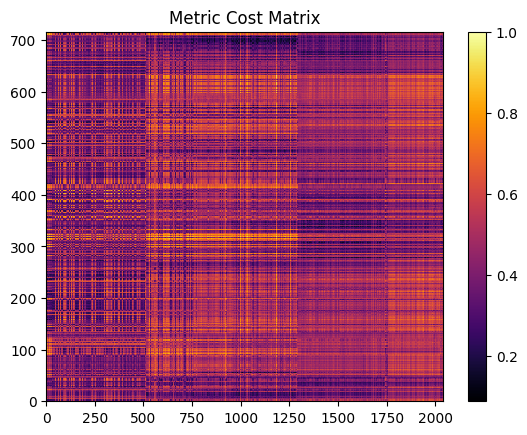

In [15]:
plt.pcolormesh(M, cmap='inferno')
plt.colorbar()
plt.title("Metric Cost Matrix")
plt.show()

### Select Samples from the Dist Matrix

In [19]:
## get the maximum cost to transport NC in WP
max_cost_per_wp = M.max(axis=0)

## index of the max
top_challenging_idx = np.argsort(max_cost_per_wp)[::-1]

## 
top_k = top_challenging_idx[:50]

top_k


array([ 917, 1197,  804, 1183, 1146,  881,  859,  816, 1063, 1275,  926,
        911,  628,  853, 1114,  858,  531,  778,  935,  882, 1224,  938,
        833, 1274, 1238,  995,  758,  895,  543, 1221,  562,  784,  885,
       1011, 1288,  832, 1255,  773, 1222,  678, 1034,  828, 1077,  985,
        533, 1018,  818,  603,  910,  849])

In [28]:
id_wp_view  = wp_view.values('id')
id_wp_view = np.array(id_wp_view)

In [ ]:
selected_view = wp_view[list(id_wp_view[top_k])]

Dataset:     dugong
Media type:  image
Num samples: 50
Sample fields:
    id:                    fiftyone.core.fields.ObjectIdField
    filepath:              fiftyone.core.fields.StringField
    tags:                  fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:            fiftyone.core.fields.DateTimeField
    last_modified_at:      fiftyone.core.fields.DateTimeField
    region:                fiftyone.core.fields.StringField
    subregion:             fiftyone.core.fields.StringField
    mission_name:          fiftyone.core.fields.StringField
    sea_state:             fiftyone.core.fields.IntField
    turbidity_global:      fiftyone.core.fields.IntField
    turbidity_local:       fiftyone.core.fields.StringField
    sun_glitter:           fiftyone.core.fields.StringField
    cloud_reflection:      fiftyone.core.fields.StringField
    habita

## Domain Adaptation with OT


each NC point is mapped to a barycentric combination of WP points, weighted by the corresponding row of the coupling matrix. So each NC embedding gets "pulled" toward the WP points it was matched to.

### Embeddings

In [ ]:
with timer("Embeddings"):
    ot_lpl1 = ot.da.SinkhornTransport(reg_e=0.05,
                                      max_iter = 1500,
                                      verbose=True,
                                      tol = 1e-8,
                                      )
    
    norm_nc = normalize(nc_emb)
    norm_wp = normalize(wp_emb)
    ot_lpl1.fit(Xs=norm_nc,
                Xt=norm_wp)

    nc_adapted = ot_lpl1.transform(Xs=norm_nc)  # shape (716, 1024)

    ## get the optimal transport plan
    ## coupling matrix
    coupling = ot_lpl1.coupling_

It.  |Err         
-------------------
    0|2.099942e-02|
   10|1.584255e-04|
   20|2.156784e-06|
   30|5.469501e-08|
   40|1.752099e-08|
   50|1.730433e-08|
   60|1.704043e-08|
   70|1.744434e-08|
   80|1.738559e-08|
   90|1.766485e-08|
  100|1.716228e-08|
  110|1.768622e-08|
  120|1.707390e-08|
  130|1.758979e-08|
  140|1.687209e-08|
  150|1.778223e-08|
  160|1.715231e-08|
  170|1.752882e-08|
  180|1.743239e-08|
  190|1.697180e-08|
It.  |Err         
-------------------
  200|1.746608e-08|
  210|1.714332e-08|
  220|1.747219e-08|
  230|1.724686e-08|
  240|1.773625e-08|
  250|1.704988e-08|
  260|1.756145e-08|
  270|1.710989e-08|
  280|1.761712e-08|
  290|1.697460e-08|
  300|1.775954e-08|
  310|1.739951e-08|
  320|1.709156e-08|
  330|1.741888e-08|
  340|1.707589e-08|
  350|1.739426e-08|
  360|1.727179e-08|
  370|1.766869e-08|
  380|1.711097e-08|
  390|1.742967e-08|
It.  |Err         
-------------------
  400|1.710790e-08|
  410|1.777518e-08|
  420|1.686516e-08|
  430|1.781887e-08|
  4

/share/home/e2406743/.conda/envs/fifty/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:902: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


#### Teste

EMD becomes infeasible on thousands of rows: (O(n³))

The transported NC embeddings nc_adapted remain (716, 1024) — each NC point is mapped to a barycentric combination of WP points, weighted by the corresponding row of the coupling matrix

In [ ]:
coupling

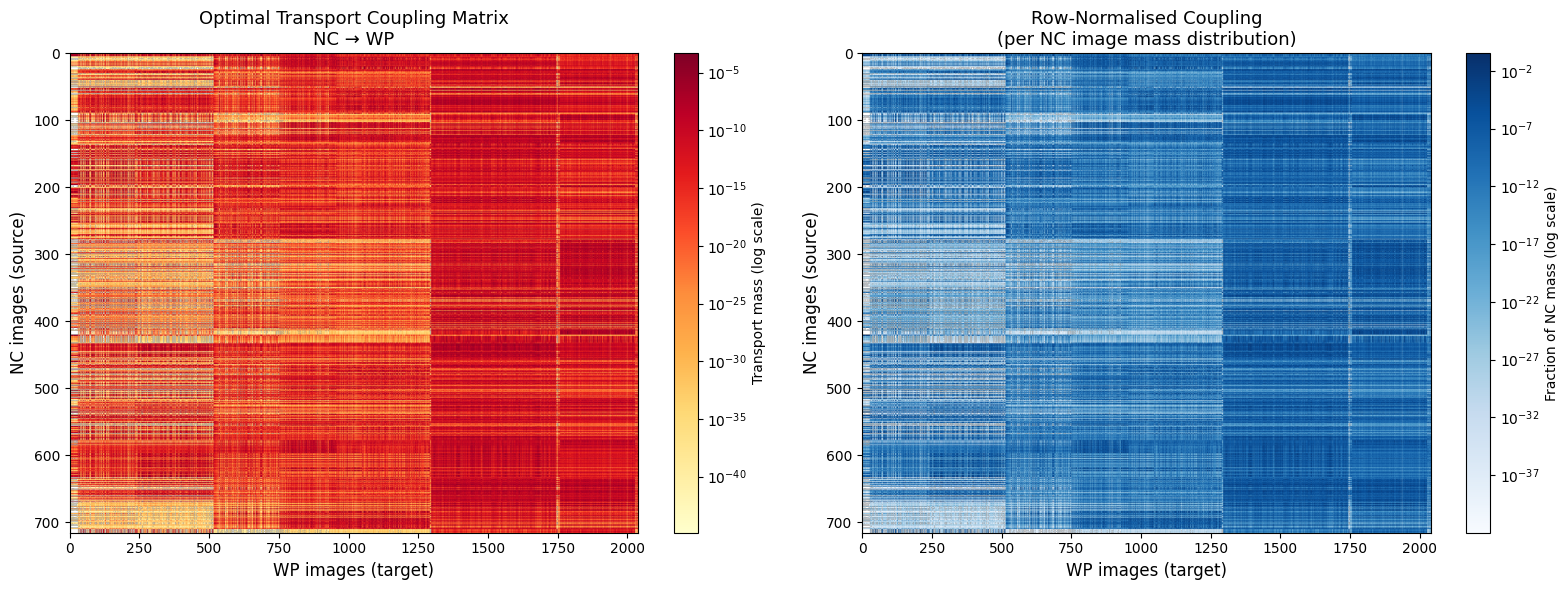

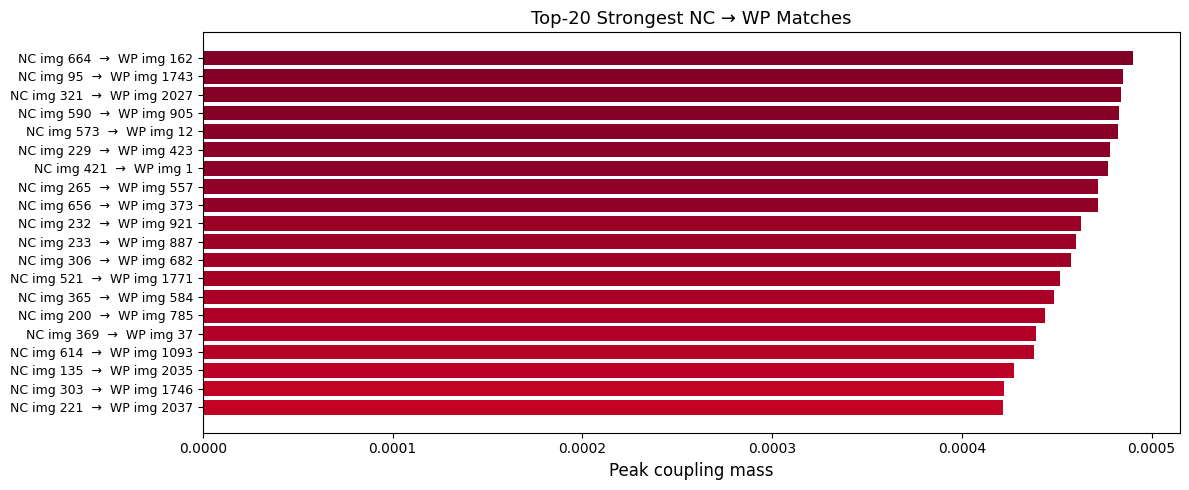

Running t-SNE on combined embeddings (this may take a minute)...


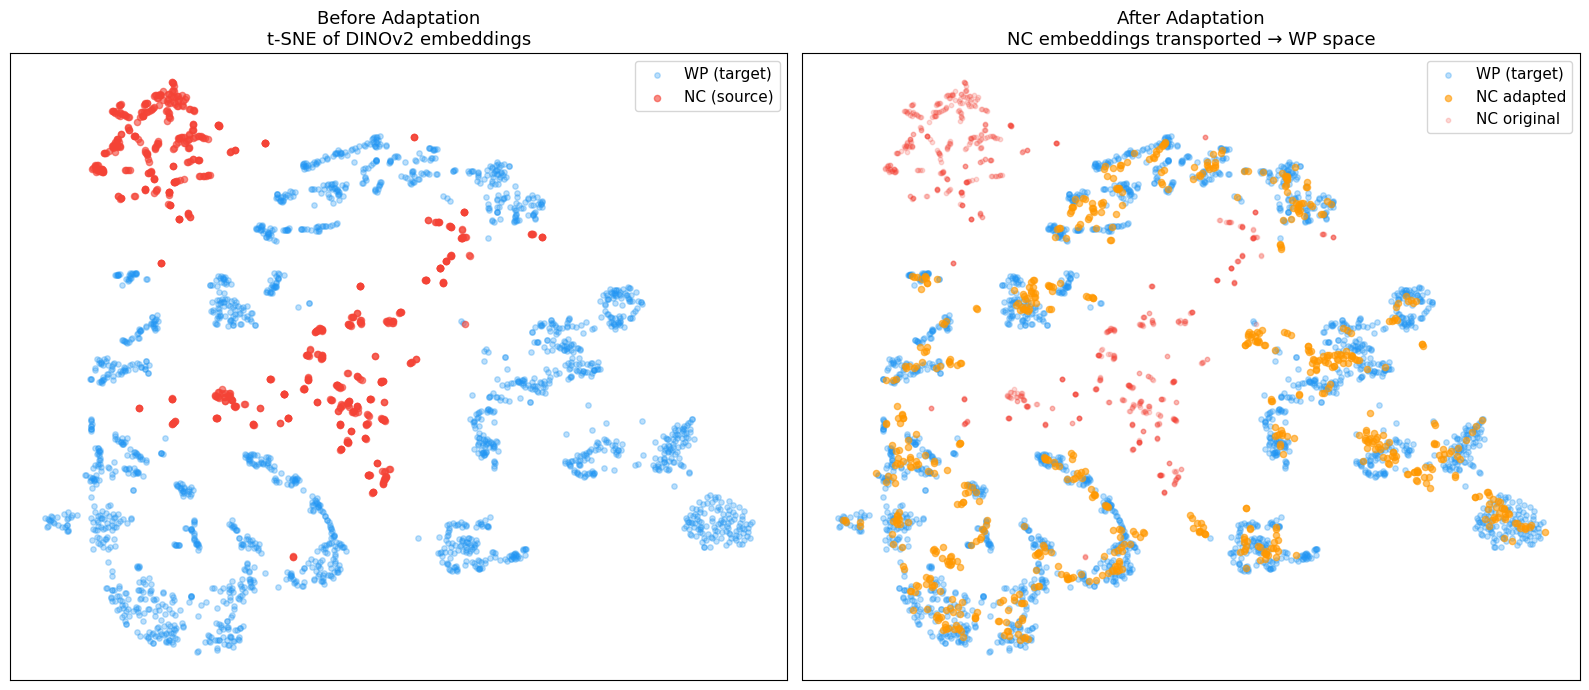

Computing Wasserstein distances (Sinkhorn)...


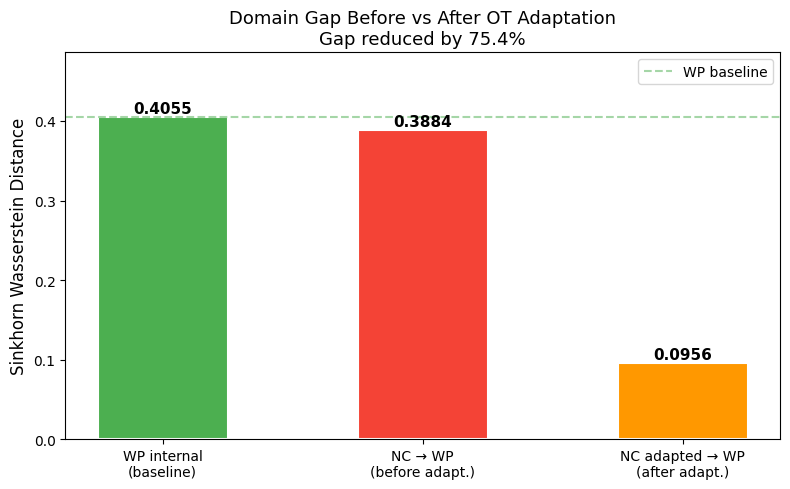


Summary:
  WP internal baseline : 0.4055
  NC → WP before adapt.: 0.3884
  NC → WP after adapt. : 0.0956
  Gap reduction        : 75.4%


In [112]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 1a: Raw coupling heatmap (log scale to reveal sparse structure) ---
ax = axes[0]
im = ax.imshow(
    coupling,
    aspect='auto',
    cmap='YlOrRd',
    norm=LogNorm(vmin=coupling[coupling > 0].min(), vmax=coupling.max())
)
plt.colorbar(im, ax=ax, label='Transport mass (log scale)')
ax.set_xlabel('WP images (target)', fontsize=12)
ax.set_ylabel('NC images (source)', fontsize=12)
ax.set_title('Optimal Transport Coupling Matrix\nNC → WP', fontsize=13)

# --- 1b: Row-normalized coupling — for each NC image, where does its mass go? ---
ax = axes[1]
coupling_rownorm = coupling / coupling.sum(axis=1, keepdims=True)
im2 = ax.imshow(
    coupling_rownorm,
    aspect='auto',
    cmap='Blues',
    norm=LogNorm(vmin=coupling_rownorm[coupling_rownorm > 0].min(),
                 vmax=coupling_rownorm.max())
)
plt.colorbar(im2, ax=ax, label='Fraction of NC mass (log scale)')
ax.set_xlabel('WP images (target)', fontsize=12)
ax.set_ylabel('NC images (source)', fontsize=12)
ax.set_title('Row-Normalised Coupling\n(per NC image mass distribution)', fontsize=13)

plt.tight_layout()
plt.savefig('coupling_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


# ================================================================
# PLOT 2: Top-k most strongly matched NC → WP pairs
# ================================================================
# For each NC image, find its single best-matched WP image

top_k = 20  # show top 20 NC images by peak coupling strength
best_wp_per_nc = np.argmax(coupling, axis=1)       # (716,) — best WP match per NC
best_mass_per_nc = coupling[np.arange(716), best_wp_per_nc]  # strength of that match

# Sort NC images by how confidently they matched something
sorted_nc = np.argsort(best_mass_per_nc)[::-1][:top_k]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    range(top_k),
    best_mass_per_nc[sorted_nc],
    color=plt.cm.YlOrRd(best_mass_per_nc[sorted_nc] / best_mass_per_nc.max())
)
ax.set_yticks(range(top_k))
ax.set_yticklabels([f'NC img {i}  →  WP img {best_wp_per_nc[i]}' for i in sorted_nc],
                   fontsize=9)
ax.set_xlabel('Peak coupling mass', fontsize=12)
ax.set_title(f'Top-{top_k} Strongest NC → WP Matches', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('top_matches.png', dpi=150, bbox_inches='tight')
plt.show()


# ================================================================
# PLOT 3: t-SNE — domain gap before and after adaptation
# ================================================================
# Stack all three point clouds: NC original, NC adapted, WP target

all_emb = np.vstack([nc_emb, nc_adapted, wp_emb])
all_emb_norm = normalize(all_emb)  # L2-normalize before t-SNE

print("Running t-SNE on combined embeddings (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, init='pca', learning_rate='auto')
emb_2d = tsne.fit_transform(all_emb_norm)

# Split back
n_nc = len(nc_emb)
n_wp = len(wp_emb)
nc_2d     = emb_2d[:n_nc]
nc_ad_2d  = emb_2d[n_nc:n_nc*2]
wp_2d     = emb_2d[n_nc*2:]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Before adaptation ---
ax = axes[0]
ax.scatter(wp_2d[:, 0],    wp_2d[:, 1],    c='#2196F3', alpha=0.3, s=15, label='WP (target)')
ax.scatter(nc_2d[:, 0],    nc_2d[:, 1],    c='#F44336', alpha=0.6, s=20, label='NC (source)')
ax.set_title('Before Adaptation\nt-SNE of DINOv2 embeddings', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

# --- After adaptation ---
ax = axes[1]
ax.scatter(wp_2d[:, 0],    wp_2d[:, 1],    c='#2196F3', alpha=0.3, s=15, label='WP (target)')
ax.scatter(nc_ad_2d[:, 0], nc_ad_2d[:, 1], c='#FF9800', alpha=0.6, s=20, label='NC adapted')
ax.scatter(nc_2d[:, 0],    nc_2d[:, 1],    c='#F44336', alpha=0.2, s=10, label='NC original')
ax.set_title('After Adaptation\nNC embeddings transported → WP space', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('tsne_adaptation.png', dpi=150, bbox_inches='tight')
plt.show()


# ================================================================
# PLOT 4: Wasserstein distance — domain gap metric
# ================================================================
# Compare: NC vs WP (before), NC adapted vs WP (after), and a baseline
# (WP vs WP internal split) to give a sense of "perfect alignment"

M_before = ot.dist(normalize(nc_emb),     normalize(wp_emb),     metric='sqeuclidean')
M_after  = ot.dist(normalize(nc_adapted), normalize(wp_emb),     metric='sqeuclidean')

# Baseline: split WP in half and compute internal distance (lower bound)
mid = len(wp_emb) // 2
M_baseline = ot.dist(normalize(wp_emb[:mid]), normalize(wp_emb[mid:]), metric='sqeuclidean')

def sinkhorn_dist(M):
    M_ = M / M.max()
    a = ot.unif(M_.shape[0])
    b = ot.unif(M_.shape[1])
    return float(ot.sinkhorn2(a, b, M_, reg=0.05))

print("Computing Wasserstein distances (Sinkhorn)...")
d_before   = sinkhorn_dist(M_before)
d_after    = sinkhorn_dist(M_after)
d_baseline = sinkhorn_dist(M_baseline)

labels   = ['WP internal\n(baseline)', 'NC → WP\n(before adapt.)', 'NC adapted → WP\n(after adapt.)']
values   = [d_baseline, d_before, d_after]
colors   = ['#4CAF50', '#F44336', '#FF9800']
reduction = (d_before - d_after) / d_before * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Sinkhorn Wasserstein Distance', fontsize=12)
ax.set_title(f'Domain Gap Before vs After OT Adaptation\n'
             f'Gap reduced by {reduction:.1f}%', fontsize=13)
ax.set_ylim(0, max(values) * 1.2)
ax.axhline(d_baseline, color='#4CAF50', linestyle='--', alpha=0.5, label='WP baseline')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('wasserstein_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSummary:")
print(f"  WP internal baseline : {d_baseline:.4f}")
print(f"  NC → WP before adapt.: {d_before:.4f}")
print(f"  NC → WP after adapt. : {d_after:.4f}")
print(f"  Gap reduction        : {reduction:.1f}%")

### TSNE space and sample selection 

In [20]:
coupling

NameError: name 'coupling' is not defined

Running t-SNE...


Min NN-distance threshold for top-100: 45.63
Max NN-distance (most isolated WP point):  52.21


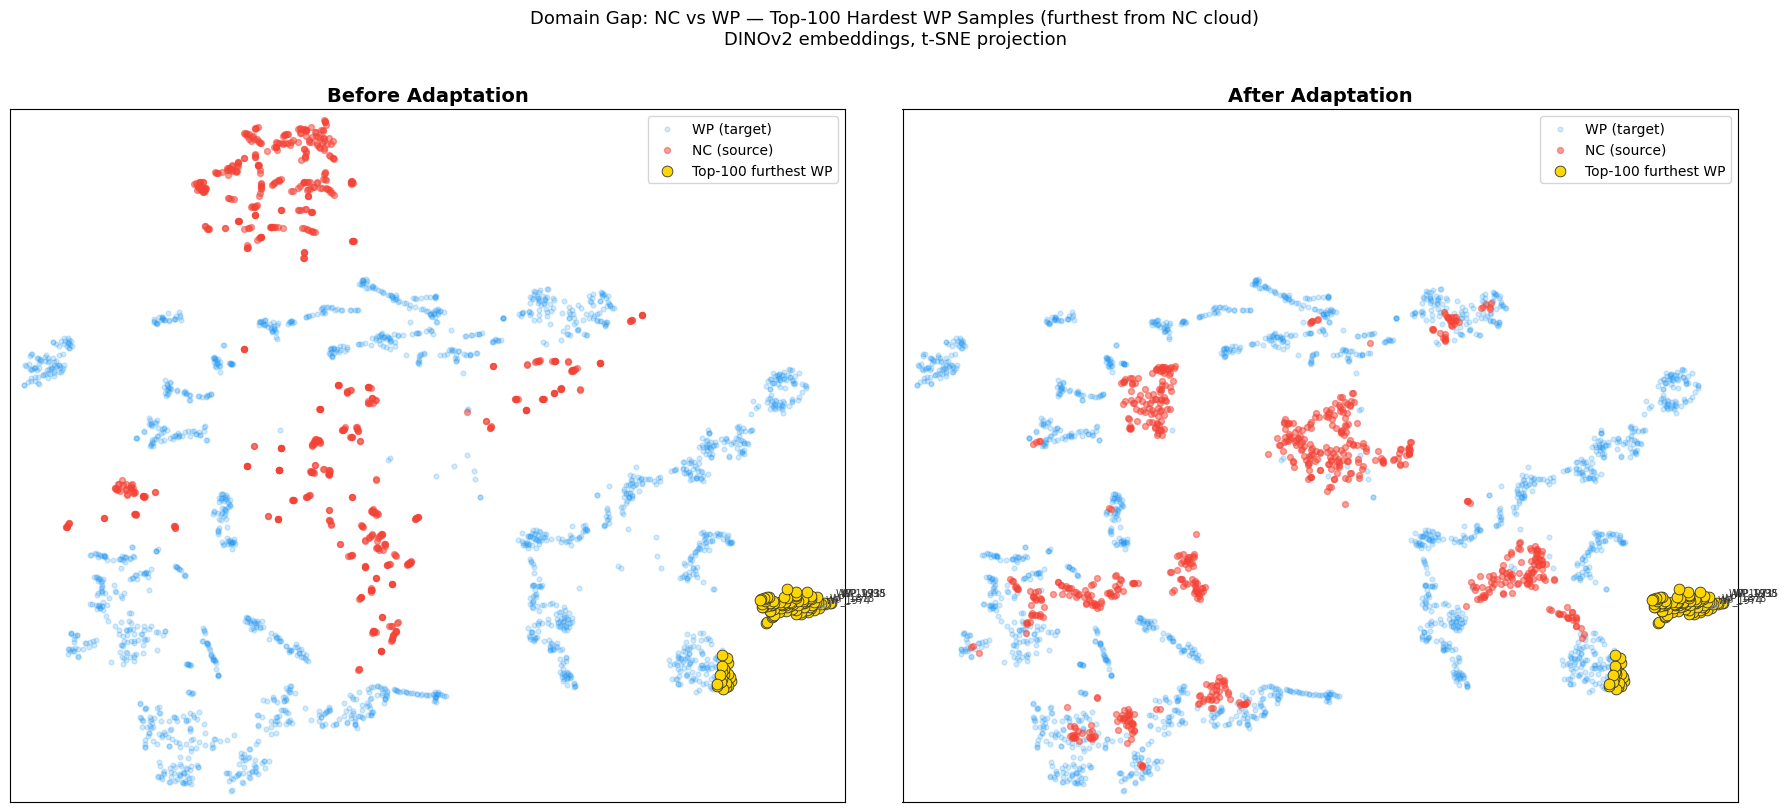

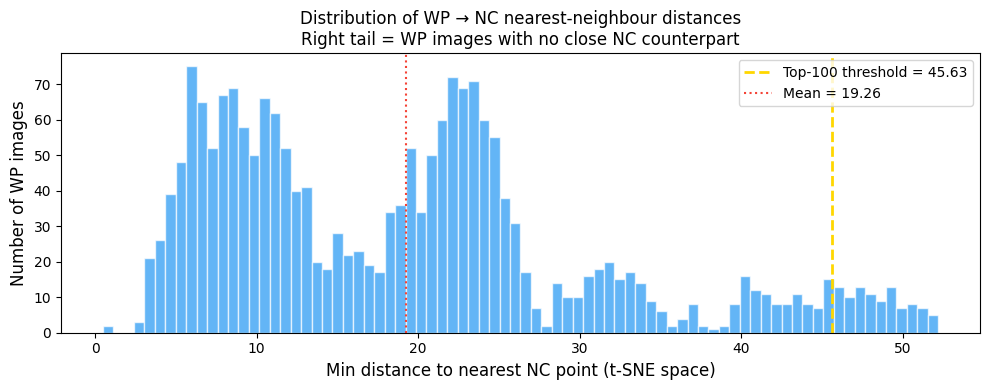


Top-100 hardest WP indices:
[1935 1998 1971 1878 1974 1930 1867 1964 1795 1992 1864 2020 1842 1776
 2024 1799 1924 1953 1973 1759 2016 1985 1932 1884 2014 1899 1852 1927
 1994 1848 1866 1819 1996 1833 1862 2009 1931 1836 1780 1929 1946 2015
 1889 2005 1822 1758 1761 1983 1827 1958 1814 1856 1813 2001 1885 1765
 1887 1854 1943 1962 1857 1787 1961 1987 1835 2011 1807 1904 1880 1939
 1975 1826 1863 1816 1820 2008 1845 1779 1853 1908 1966 1910 1858 1871
 1778 2012 1914 1768 1808 1791 1956 1947 1810 1886 1984 1849 1837 1978
 1821 1915]


In [ ]:
from scipy.spatial.distance import cdist

# ---------------------------------------------------------------
# Assumes:
#   nc_emb:     (716, 1024)
#   wp_emb:     (2039, 1024)
#   nc_adapted: (716, 1024)
#   coupling:   (716, 2039)
# ---------------------------------------------------------------

## 
TOP_K = 100

# ================================================================
# STEP 1: Run t-SNE on all three point clouds jointly
# ================================================================
# Must be joint so all points share the same 2D coordinate system

nc_norm     = normalize(nc_emb)
wp_norm     = normalize(wp_emb)
nc_ad_norm  = normalize(nc_adapted)

all_emb = np.vstack([nc_norm, nc_ad_norm, wp_norm])  # (716+716+2039, 1024)

print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, init='pca', learning_rate='auto')
emb_2d = tsne.fit_transform(all_emb)

n_nc = len(nc_emb)
n_wp = len(wp_emb)

nc_2d    = emb_2d[:n_nc]                    # (716, 2)
nc_ad_2d = emb_2d[n_nc:n_nc*2]             # (716, 2)
wp_2d    = emb_2d[n_nc*2:]                 # (2039, 2)


# ================================================================
# STEP 2: Select top-100 WP samples furthest from NC cloud
# ================================================================
# For each WP point, compute its minimum distance to any NC point
# in t-SNE space — this is the "nearest NC neighbour distance"
# A high value means: no NC sample is close → it's in a coverage gap

# pairwise distances between all WP and all NC points in 2D t-SNE space
dists_wp_to_nc = cdist(wp_2d, nc_2d, metric='euclidean')  # (2039, 716)

# For each WP point: distance to its closest NC neighbour
min_dist_to_nc = dists_wp_to_nc.min(axis=1)               # (2039,)

# Top-100 WP indices with largest min-distance (furthest from NC)
top100_idx = np.argsort(min_dist_to_nc)[::-1][:TOP_K]
top100_2d  = wp_2d[top100_idx]                             # (100, 2)

print(f"Min NN-distance threshold for top-{TOP_K}: {min_dist_to_nc[top100_idx[-1]]:.2f}")
print(f"Max NN-distance (most isolated WP point):  {min_dist_to_nc[top100_idx[0]]:.2f}")


# ================================================================
# STEP 3: Visualize — before and after adaptation, with hard samples
# ================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# shared axis limits
xmin, xmax = emb_2d[:, 0].min() - 2, emb_2d[:, 0].max() + 2
ymin, ymax = emb_2d[:, 1].min() - 2, emb_2d[:, 1].max() + 2

for ax, title, nc_points in zip(
    axes,
    ['Before Adaptation', 'After Adaptation'],
    [nc_2d, nc_ad_2d]
):
    # All WP points (background)
    ax.scatter(wp_2d[:, 0], wp_2d[:, 1],
               c='#2196F3', alpha=0.2, s=12, label='WP (target)', zorder=1)

    # NC points
    ax.scatter(nc_points[:, 0], nc_points[:, 1],
               c='#F44336', alpha=0.5, s=18, label='NC (source)', zorder=2)


    # Annotate a few of the most extreme ones
    for rank, idx in enumerate(top100_idx[:5]):
        ax.annotate(
            f'WP_{idx}',
            xy=wp_2d[idx],
            xytext=(wp_2d[idx][0] + 1.5, wp_2d[idx][1] + 1.5),
            fontsize=7,
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
            color='#333'
        )

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    f'Domain Gap: NC vs WP — Top-{TOP_K} Hardest WP Samples (furthest from NC cloud)\n'
    f'DINOv2 embeddings, t-SNE projection',
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig('hard_samples_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


# ================================================================
# STEP 4: Distance distribution — put the threshold in context
# ================================================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(min_dist_to_nc, bins=80, color='#2196F3', alpha=0.7, edgecolor='white')

ax.set_xlabel('Min distance to nearest NC point (t-SNE space)', fontsize=12)
ax.set_ylabel('Number of WP images', fontsize=12)
ax.set_title('Distribution of WP → NC nearest-neighbour distances\n'
             'Right tail = WP images with no close NC counterpart', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('hard_samples_distribution.png', dpi=150, bbox_inches='tight')
plt.show()





### Style transfering

In [ ]:

rng = np.random.RandomState(42)


def im2mat(img):
    """Converts and image to matrix (one pixel per line)"""
    return img.reshape((img.shape[0] * img.shape[1], img.shape[2]))


def mat2im(X, shape):
    """Converts back a matrix to an image"""
    return X.reshape(shape)


def minmax(img):
    return np.clip(img, 0, 1)

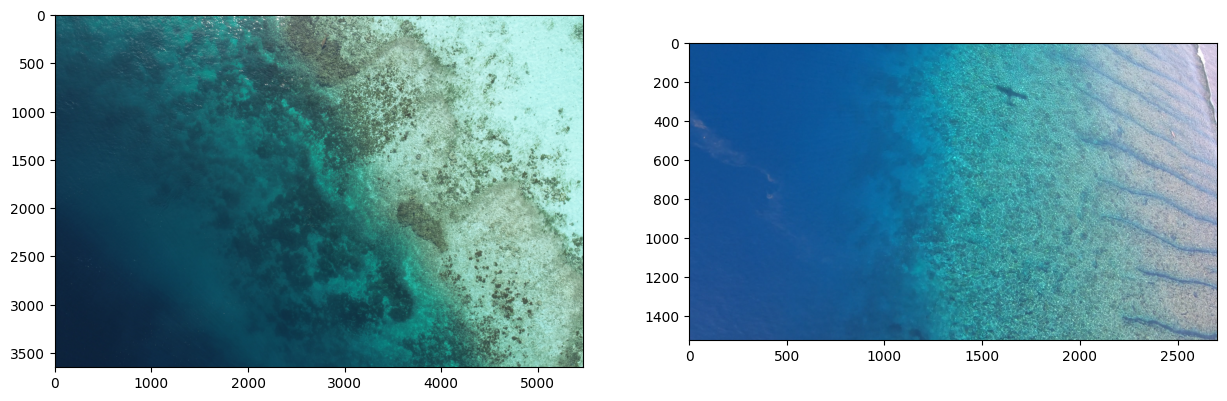

In [57]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(wp_img)
ax[1].imshow(nc_img)

In [ ]:

I1 = cv2.cvtColor(cv2.imread(wp_view.first().filepath),
                        cv2.COLOR_BGR2RGB) / 256
I2 = cv2.cvtColor(cv2.imread(nc_view.first().filepath),
                        cv2.COLOR_BGR2RGB) / 256

X1 = im2mat(wp_img)
X2 = im2mat(nc_img)

# # training samples
## uses 500 samples to train the OT 
## here it is sampling the X1 matrix where each line is a pixel [r,g,b]
nb = 500
idx1 = rng.randint(X1.shape[0], size=(nb,))
idx2 = rng.randint(X2.shape[0], size=(nb,))

Xs = X1[idx1, :]
Xt = X2[idx2, :]

In [75]:
X1.shape

(19961856, 3)

In [ ]:
with timer("EMDTransport"):
    ot_emd = ot.da.EMDTransport()
    ot_emd.fit(Xs=Xs, Xt=Xt)
    transp_Xs_emd = ot_emd.transform(Xs=X1)
    Image_emd = minmax(mat2im(transp_Xs_emd, I1.shape))


with timer("SinkhornTransport"):
    ot_sinkhorn = ot.da.SinkhornTransport(reg_e=1e-1)
    ot_sinkhorn.fit(Xs=Xs, Xt=Xt)
    transp_Xs_sinkhorn = ot_sinkhorn.transform(Xs=X1)
    Image_sinkhorn = minmax(mat2im(transp_Xs_sinkhorn, I1.shape))


with timer("Mapping Linear"):
    ot_mapping_linear = ot.da.MappingTransport(
        mu=1e0, eta=1e-8, bias=True, max_iter=20, verbose=True
    )
    ot_mapping_linear.fit(Xs=Xs, Xt=Xt)
    X1tl = ot_mapping_linear.transform(Xs=X1)
    Image_mapping_linear = minmax(mat2im(X1tl, I1.shape))


with timer("Mapping Gaussian"):
    ot_mapping_gaussian = ot.da.MappingTransport(
        mu=1e0, eta=1e-2, sigma=1, bias=False, max_iter=10, verbose=True
    )
    ot_mapping_gaussian.fit(Xs=Xs, Xt=Xt)
    X1tn = ot_mapping_gaussian.transform(Xs=X1)
    Image_mapping_gaussian = minmax(mat2im(X1tn, I1.shape))

In [ ]:

# EMDTransport
ot_emd = ot.da.EMDTransport()
ot_emd.fit(Xs=Xs, Xt=Xt)
transp_Xs_emd = ot_emd.transform(Xs=X1)
Image_emd = minmax(mat2im(transp_Xs_emd, I1.shape))

# SinkhornTransport
ot_sinkhorn = ot.da.SinkhornTransport(reg_e=1e-1)
ot_sinkhorn.fit(Xs=Xs, Xt=Xt)
transp_Xs_sinkhorn = ot_sinkhorn.transform(Xs=X1)
Image_sinkhorn = minmax(mat2im(transp_Xs_sinkhorn, I1.shape))

ot_mapping_linear = ot.da.MappingTransport(
    mu=1e0, eta=1e-8, bias=True, max_iter=20, verbose=True
)
ot_mapping_linear.fit(Xs=Xs, Xt=Xt)

X1tl = ot_mapping_linear.transform(Xs=X1)
Image_mapping_linear = minmax(mat2im(X1tl, I1.shape))

ot_mapping_gaussian = ot.da.MappingTransport(
    mu=1e0, eta=1e-2, sigma=1, bias=False, max_iter=10, verbose=True
)
ot_mapping_gaussian.fit(Xs=Xs, Xt=Xt)

X1tn = ot_mapping_gaussian.transform(Xs=X1)  # use the estimated mapping
Image_mapping_gaussian = minmax(mat2im(X1tn, I1.shape))

It.  |Loss        |Delta loss
--------------------------------
    0|3.148935e+01|0.000000e+00
    1|3.049704e+01|-3.151276e-02
    2|3.046175e+01|-1.157072e-03
    3|3.044609e+01|-5.139872e-04
    4|3.043710e+01|-2.954632e-04
    5|3.043112e+01|-1.963712e-04
    6|3.042688e+01|-1.392864e-04
    7|3.042371e+01|-1.041648e-04
    8|3.042126e+01|-8.066958e-05
    9|3.041928e+01|-6.505586e-05
   10|3.041766e+01|-5.319350e-05
   11|3.041632e+01|-4.411764e-05
   12|3.041517e+01|-3.780144e-05
   13|3.041421e+01|-3.161693e-05
   14|3.041334e+01|-2.838051e-05
   15|3.041259e+01|-2.481597e-05
   16|3.041194e+01|-2.118339e-05
   17|3.041135e+01|-1.954112e-05
   18|3.041082e+01|-1.742761e-05
   19|3.041035e+01|-1.545387e-05
It.  |Loss        |Delta loss
--------------------------------
   20|3.040992e+01|-1.416140e-05
It.  |Loss        |Delta loss
--------------------------------
    0|3.653262e+01|0.000000e+00
    1|3.538628e+01|-3.137845e-02
    2|3.533076e+01|-1.569150e-03
    3|3.530877e+01|-6

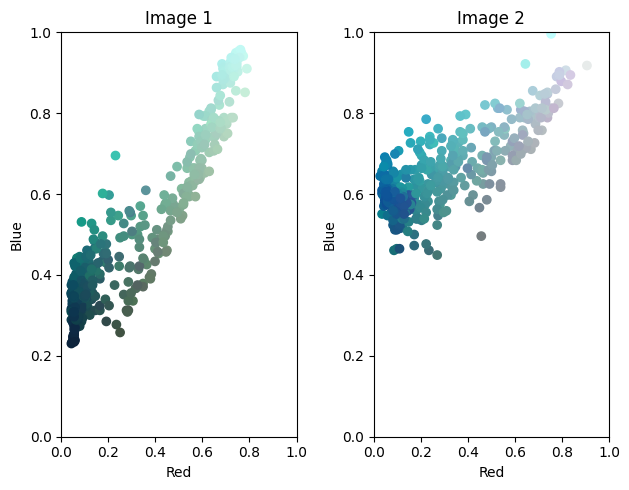

In [59]:
plt.figure(2, figsize=(6.4, 5))

plt.subplot(1, 2, 1)
plt.scatter(Xs[:, 0], Xs[:, 2], c=Xs)
plt.axis([0, 1, 0, 1])
plt.xlabel("Red")
plt.ylabel("Blue")
plt.title("Image 1")

plt.subplot(1, 2, 2)
plt.scatter(Xt[:, 0], Xt[:, 2], c=Xt)
plt.axis([0, 1, 0, 1])
plt.xlabel("Red")
plt.ylabel("Blue")
plt.title("Image 2")
plt.tight_layout()

TypeError: suptitle() takes 1 positional argument but 2 were given

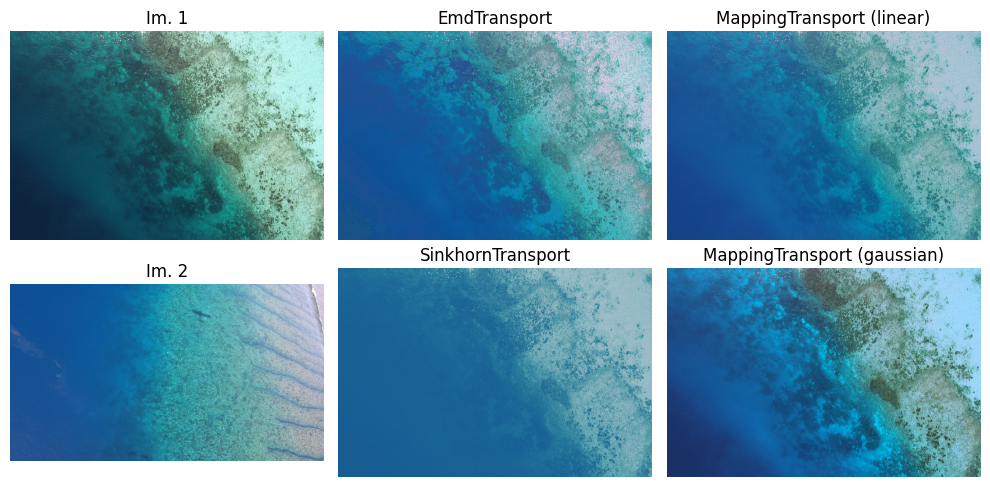

In [63]:
plt.figure(2, figsize=(10, 5))

plt.subplot(2, 3, 1)
plt.imshow(wp_img)
plt.axis("off")
plt.title("Im. 1")

plt.subplot(2, 3, 4)
plt.imshow(nc_img)
plt.axis("off")
plt.title("Im. 2")

plt.subplot(2, 3, 2)
plt.imshow(Image_emd)
plt.axis("off")
plt.title("EmdTransport")

plt.subplot(2, 3, 5)
plt.imshow(Image_sinkhorn)
plt.axis("off")
plt.title("SinkhornTransport")

plt.subplot(2, 3, 3)
plt.imshow(Image_mapping_linear)
plt.axis("off")
plt.title("MappingTransport (linear)")

plt.subplot(2, 3, 6)
plt.imshow(Image_mapping_gaussian)
plt.axis("off")
plt.title("MappingTransport (gaussian)")
plt.tight_layout()

plt.suptitle("Style Transfering with Optimal Transport",
             [0.,0.8])
plt.show()

In [ ]:
# Uniform weights
a = ot.unif(len(Xs_NC))
b = ot.unif(len(Xt_WP))

In [29]:
M.shape

(716, 716)

In [28]:
# Uniform weights
a = ot.unif(len(wp_emb))
b = ot.unif(len(nc_emb))

# Wasserstein-2 distance (exact, but expensive for large n)
W2 = ot.emd2(a, b, M)
print(f"Domain gap (W2): {W2:.4f}")

AssertionError: Dimension mismatch, check dimensions of M with a and b

In [ ]:
Xs_NC = Xs_NC / np.linalg.norm(Xs_NC, axis=1, keepdims=True)
Xt_WP = Xt_WP / np.linalg.norm(Xt_WP, axis=1, keepdims=True)
M = ot.dist(Xs_NC, Xt_WP, metric='sqeuclidean')  # equivalent to cosine after L2-norm

In [ ]:
# EMD Transport
ot_emd = ot.da.EMDTransport()
ot_emd.fit(Xs=Xs, Xt=Xt)

# Sinkhorn Transport
ot_sinkhorn = ot.da.SinkhornTransport(reg_e=0.01)
ot_sinkhorn.fit(Xs=Xs, Xt=Xt)

# EMD Transport with Laplacian regularization
ot_emd_laplace = ot.da.EMDLaplaceTransport(reg_lap=100, reg_src=1)
ot_emd_laplace.fit(Xs=Xs, Xt=Xt)

# transport source samples onto target samples
transp_Xs_emd = ot_emd.transform(Xs=Xs)
transp_Xs_sinkhorn = ot_sinkhorn.transform(Xs=Xs)
transp_Xs_emd_laplace = ot_emd_laplace.transform(Xs=Xs)

## Compute Kmeans distance on tsne reduction

In [7]:
points_tsne = dataset.values("full_emb_tsne_dinov3")

In [8]:
len(points_tsne)

2755

In [11]:
np.array(points_tsne).shape

(2755, 2)

In [15]:
data.shape

(2755, 2)

In [ ]:
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd 

data = np.array(points_tsne)
estimator = make_pipeline(StandardScaler(),
                        KMeans(init="k-means++",
                                n_clusters=7,
                                random_state=42)).fit(data)



labels = estimator.fit_predict(data)




In [45]:
len(np.unique(labels))

7

In [47]:
np.unique(labels)

array([0, 1, 2, 3, 4, 5, 6], dtype=int32)

In [39]:
ss = pd.Series(labels)
ss.loc[ss==2].index

## fileid
id_whole = np.array(dataset.values('id'))

## id nc
id_nc = np.array(nc_view.values('id'))

## id_wp
id_wp = np.array(wp_view.values('id'))

In [53]:
teste = ss.loc[ss==2][pd.Series(ss.loc[ss==2].index).isin(idx_wp).values]

In [54]:
## get the maximum cost to transport NC in WP
max_cost_per_wp = M.max(axis=0)

## index of the max
top_challenging_idx = np.argsort(max_cost_per_wp)[::-1]


In [61]:
len(nc_view)

716

In [62]:
teste.index = teste.index - 715

In [63]:
teste

31     2
32     2
33     2
34     2
35     2
      ..
229    2
230    2
231    2
233    2
238    2
Length: 112, dtype: int32

In [64]:
max_cost_per_wp[teste.index]

array([0.8226269 , 0.80173266, 0.8207096 , 0.8299975 , 0.8431141 ,
       0.87844425, 0.82506067, 0.86157304, 0.82545334, 0.846988  ,
       0.8318179 , 0.8644121 , 0.8548443 , 0.90597904, 0.87684137,
       0.84501463, 0.80936813, 0.8436617 , 0.7717006 , 0.82712764,
       0.88798064, 0.8278201 , 0.8192042 , 0.8485772 , 0.8433277 ,
       0.78522426, 0.83528316, 0.77844703, 0.7993854 , 0.7905758 ,
       0.8605761 , 0.82743114, 0.7708353 , 0.8359348 , 0.77169716,
       0.80493397, 0.8255449 , 0.8944071 , 0.8512283 , 0.850196  ,
       0.889529  , 0.7622315 , 0.8597545 , 0.86017627, 0.8571522 ,
       0.87319684, 0.8511737 , 0.81774515, 0.77972335, 0.8977313 ,
       0.8614742 , 0.84123063, 0.82797   , 0.8351781 , 0.84419227,
       0.89877504, 0.8802003 , 0.7741904 , 0.83626884, 0.8139087 ,
       0.829332  , 0.77455616, 0.85080224, 0.82882315, 0.78517246,
       0.7942541 , 0.833797  , 0.8783371 , 0.83589995, 0.8251277 ,
       0.8327703 , 0.8399259 , 0.75079536, 0.8509172 , 0.82404

In [77]:
pd.Series(ss_labels.loc[ss_labels==k].index).isin(idx_wp).values

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [78]:
ss_labels.loc[ss_labels==k][pd.Series(ss_labels.loc[ss_labels==k].index).isin(idx_wp).values]

2010    0
2012    0
2014    0
2015    0
2018    0
       ..
2745    0
2748    0
2750    0
2753    0
2754    0
Length: 333, dtype: int32

In [79]:
## labels
ss_labels = pd.Series(labels)

# idx_wp_by_id = 
ss_whole = pd.Series(id_whole)

## find all the index (dataset) that belongs to WP 
idx_wp = list(ss_whole[~ss_whole.isin(id_nc)].index)

## filter this index to match to label assigned 
final_dict = {}
for k in range(len(np.unique(labels))):
    print(f" Running label:{k}")
    ## check if there is any index inside the index assigned to WP
    if bool(pd.Series(ss_labels.loc[ss_labels==k].index).isin(idx_wp).any()):

        ## filter to only return existents index present in WP
        filtered = ss_labels.loc[ss_labels==k][pd.Series(ss_labels.loc[ss_labels==k].index).isin(idx_wp).values]

        # translate the index to subtract the beggining
        ## the dataset is kind of a vstack of nc and wp.
        filtered.index = filtered.index - len(nc_view)

        ## retrieve the max cost over the region delimited by KMeans
        region_max_cost = max_cost_per_wp[filtered.index]

        ## sort 
        ## index of the max
        top_challenging_idx = np.argsort(region_max_cost)[::-1]

        ## add these index into a dict
        final_dict[k] = top_challenging_idx[:20]
    else:
        final_dict[k] = None

 Running label:0
 Running label:1
 Running label:2
 Running label:3
 Running label:4
 Running label:5
 Running label:6


In [86]:
wp_view

Dataset:     dugong
View name:   West_Papua
Media type:  image
Num samples: 2039
Sample fields:
    id:                    fiftyone.core.fields.ObjectIdField
    filepath:              fiftyone.core.fields.StringField
    tags:                  fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:              fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:            fiftyone.core.fields.DateTimeField
    last_modified_at:      fiftyone.core.fields.DateTimeField
    region:                fiftyone.core.fields.StringField
    subregion:             fiftyone.core.fields.StringField
    mission_name:          fiftyone.core.fields.StringField
    sea_state:             fiftyone.core.fields.IntField
    turbidity_global:      fiftyone.core.fields.IntField
    turbidity_local:       fiftyone.core.fields.StringField
    sun_glitter:           fiftyone.core.fields.StringField
    cloud_reflection:      fiftyone.core.fie

In [ ]:
wp_id_values = np.array(wp_view.values('id'))
wp_points = np.array(wp_view.values('full_emb_tsne_dinov3'))
points_tsne

In [ ]:
final_list = np.concatenate(list(final_dict.values()))
len(final_list)

## filter the points matching only the points of WP
filtered_points = wp_points[final_list]

140

In [93]:
points_tsne = np.array(points_tsne)

In [94]:
## plot to see those points 
import plotly.graph_objects as go

fig = go.Figure()

# Transparent full dataset
fig.add_trace(
    go.Scatter(
        x=points_tsne[:,0],
        y=points_tsne[:,1],
        mode="markers",
        name="All points",
        marker=dict(
            size=6,
            color="blue",
            opacity=0.25
        )
    )
)

# Highlighted filtered dataset
fig.add_trace(
    go.Scatter(
        x=filtered_points[:,0],
        y=filtered_points[:,1],
        mode="markers",
        name="Filtered points",
        marker=dict(
            size=10,
            color="red",
            line=dict(width=1, color="black")
        )
    )
)

fig.update_layout(
    title="Full dataset vs filtered subset",
    xaxis_title="X",
    yaxis_title="Y",
    template="plotly_white"
)

fig.show()

In [19]:
def plot_kmeans_voronoi(X, n_clusters=8, h=0.02):
    
    kmeans = KMeans(n_clusters=n_clusters, init="k-means++", n_init=20, random_state=42)
    labels = kmeans.fit_predict(X)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8,6))

    plt.imshow(
        Z,
        interpolation="nearest",
        extent=(xx.min(), xx.max(), yy.min(), yy.max()),
        cmap=plt.cm.Paired,
        aspect="auto",
        origin="lower",
    )

    plt.scatter(X[:,0], X[:,1], c=labels, s=5, cmap="tab10")

    centroids = kmeans.cluster_centers_

    plt.scatter(
        centroids[:,0],
        centroids[:,1],
        marker="X",
        s=200,
        linewidths=3,
        color="white",
        edgecolors="black",
        zorder=10,
    )

    plt.title("KMeans clustering with Voronoi regions")
    plt.xticks([])
    plt.yticks([])
    plt.show()

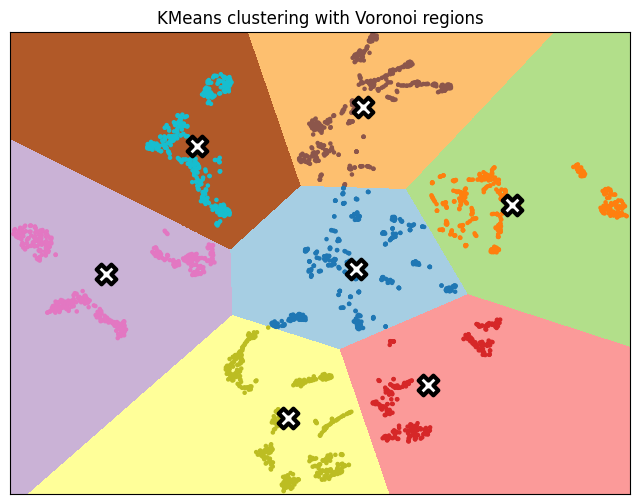

In [21]:
plot_kmeans_voronoi(data, n_clusters=7)

## SSIM image properties

In [14]:
from skimage.metrics import structural_similarity as ssim
import numpy as np
from skimage.metrics import structural_similarity as ssim


In [18]:

def compute_ssim_adapted(image1,
                          image2,
                            w1=0.5,
                            w2=0.5,
                            C1=1e-4,
                            C2=1e-4,
                            C3=1e-5
                            ):
    """
    Computes the adapted SSIM metric between two images.
    
    Args:
        image1 (np.ndarray): First image (grayscale or single channel, 2D array).
        image2 (np.ndarray): Second image (same dimensions as image1).
        w1 (float): Weight applied to the brightness term. Default = 0.5.
        w2 (float): Weight applied to the contrast/structure term. Default = 0.5.
        C1 (float): Stabilization constant for luminance.
        C2 (float): Stabilization constant for contrast.
        C3 (float): Stabilization constant for structure.

    Returns:
        float: Adapted SSIM distance (lower values reflect higher similarity).
    """
    # Mean and variance calculations
    mu1 = np.mean(image1)
    mu2 = np.mean(image2)
    sigma1_sq = np.var(image1)
    sigma2_sq = np.var(image2)
    sigma12 = np.cov(image1.ravel(), image2.ravel())[0, 1]

    # Luminance term (brightness similarity)
    l = (2 * mu1 * mu2 + C1) / (mu1**2 + mu2**2 + C1)

    # Contrast term
    c = (2 * np.sqrt(sigma1_sq) * np.sqrt(sigma2_sq) + C2) / (sigma1_sq + sigma2_sq + C2)

    # Structure term
    s = (sigma12 + C3) / (np.sqrt(sigma1_sq) * np.sqrt(sigma2_sq) + C3)

    # Adapted SSIM distance metric
    adapted_distance = w1 * (1 - l) + w2 * (1 - np.abs(c * s))
    
    return adapted_distance



In [22]:
I1.shape ,I2.shape

((3648, 5472, 3), (1520, 2704, 3))

In [19]:

# Compute adapted SSIM distance
adapted_distance = compute_ssim_adapted(I1, I2,
                                            w1=0.5,
                                            w2=0.5)
print(f"Adapted SSIM Distance: {adapted_distance:.4f}")


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 59885568 and the array at index 1 has size 12330240

In [21]:
np.cov(I1.ravel(), I2.ravel())

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 59885568 and the array at index 1 has size 12330240

In [15]:

I1 = cv2.cvtColor(cv2.imread(wp_view.first().filepath),
                        cv2.COLOR_BGR2RGB) / 256
I2 = cv2.cvtColor(cv2.imread(nc_view.first().filepath),
                        cv2.COLOR_BGR2RGB) / 256

(3648, 5472, 3)

In [ ]:
def create_batches(S, T, batch_size):
    np.random.shuffle(S)
    np.random.shuffle(T)
    S_batches = [S[i:i + batch_size] for i in range(0, len(S), batch_size)]
    T_batches = [T[i:i + batch_size] for i in range(0, len(T), batch_size)]
    return S_batches, T_batches


In [ ]:
cost_matrix = np.zeros((len(S), len(T)))

for idx, (S_batch, T_batch) in enumerate(zip(S_batches, T_batches)):
    for i, s in enumerate(S_batch):
        for j, t in enumerate(T_batch):
            cost_matrix[idx * batch_size + i, idx * batch_size + j] = adapted_ssim(s, t, w1=0.6, w2=0.4)


In [ ]:
def progressive_filling(cost_matrix, S_batches, T_batches):
    for batch_idx, (S_batch, T_batch) in enumerate(zip(S_batches, T_batches)):
        start_row = batch_idx * len(S_batch)
        start_col = batch_idx * len(T_batch)
        cost_matrix[start_row:start_row + len(S_batch),
                    start_col:start_col + len(T_batch)] = compute_ssim_cost(S_batch, T_batch)


In [ ]:
def ssim_cost_batched(source_images, target_images, batch_size=100):
    cost_matrix = np.zeros((len(source_images), len(target_images)))

    for batch_idx, (S_batch, T_batch) in enumerate(zip(source_batches, target_batches)):
        for i, source_image in enumerate(S_batch):
            for j, target_image in enumerate(T_batch):
                cost_matrix[batch_idx * batch_size + i, batch_idx * batch_size + j] = adapted_ssim(source_image, target_image)

    return cost_matrix


## Maximum Likelihood Estimator

In [23]:
import skdim

In [26]:
nc_norm.shape

(716, 1024)

In [27]:
#estimate global intrinsic dimension
danco = skdim.id.DANCo().fit(nc_norm)
#estimate local intrinsic dimension (dimension in k-nearest-neighborhoods around each point):
lpca = skdim.id.lPCA().fit_pw(nc_norm,
                              n_neighbors = 100,
                              n_jobs = 1)

#get estimated intrinsic dimension
print(danco.dimension_, np.mean(lpca.dimension_pw_))

1021.9714451022971 15.737430167597765


In [ ]:
def calculate_MLE(dataset: np.ndarray, 
                  list_neighboors: list = [3,5,10,20],
                  verbose=True):
    """
    Computes Maximum Likelihood Estimation for a set of neighboors,
    Returns:
        list of MLE distances for each neighboor
    """
    results = {}
    for k in list_neighboors:
        if verbose:
            print(f"running {k}")
            with timer(f'k_{k}'):
                #estimate local intrinsic dimension (dimension in k-nearest-neighborhoods around each point):
                lpca = skdim.id.lPCA().fit_pw(dataset,
                                            n_neighbors = k,
                                            n_jobs = 1)
                results[k] = np.mean(lpca.dimension_pw_)
        else:
        #estimate local intrinsic dimension (dimension in k-nearest-neighborhoods around each point):
            lpca = skdim.id.lPCA().fit_pw(dataset,
                                        n_neighbors = k,
                                        n_jobs = 1)
            results[k] = np.mean(lpca.dimension_pw_)
    return results


In [65]:
datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm}

output = {}
for k,v in datasets_l.items():
    print(f"Running:{k}")
    results = calculate_MLE(dataset = v,
                            list_neighboors=[3,5,10,20])
    output[k] = results

Running:WP
running 3
k_3: 0.8918 s
running 5
k_5: 1.1597 s
running 10
k_10: 1.6092 s
running 20
k_20: 4.0017 s
Running:NC
running 3
k_3: 0.3672 s
running 5
k_5: 0.3693 s
running 10
k_10: 0.5990 s
running 20
k_20: 1.4773 s


In [66]:
df = pd.DataFrame().from_dict(output)
df  = df.reset_index().rename(columns={'index':'N_neighboor'})

In [47]:
df

,N_neighboor,WP,NC
0,3,1.992153,2.000000
1,5,3.975478,3.953911
2,10,8.816086,7.209497
3,20,14.524277,9.342179


In [67]:
df_melted = df.melt(id_vars = 'N_neighboor',
        var_name='Group',
        value_name='Value')

df_melted

,N_neighboor,Group,Value
0,3,WP,1.992153
1,5,WP,3.975478
2,10,WP,8.816086
3,20,WP,14.524277
4,3,NC,2.000000
5,5,NC,3.953911
6,10,NC,7.209497
7,20,NC,9.342179


Text(0, 0.5, 'Values')

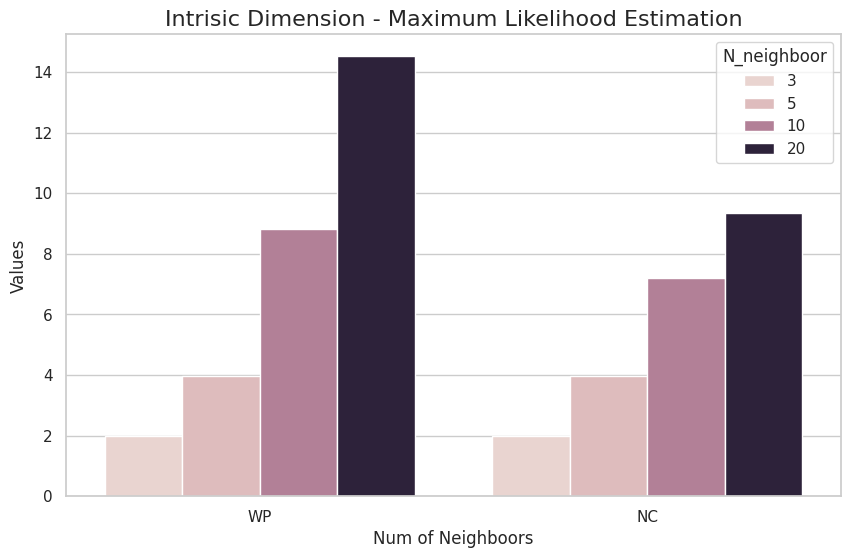

In [68]:
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
plot = sns.barplot(data=df_melted, x='Group',
                    y='Value',
                    hue='N_neighboor')

# Customizing labels
plot.set_title('Intrisic Dimension - Maximum Likelihood Estimation', fontsize=16)
plot.set_xlabel('Num of Neighboors', fontsize=12)
plot.set_ylabel('Values', fontsize=12)

### Bootstraping MLE

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

datasets_l ={'WP': wp_norm, 
             'NC' : nc_norm}
n_iterations = 100
sample_size = 100
neighbors = [3, 5, 10, 20]
all_results = []

for name, data in datasets_l.items():
    print(f"Processing Distribution for: {name}")
    
    for i in range(n_iterations):
        # randomly sample indices
        indices = np.random.choice(data.shape[0], size=sample_size, replace=False)
        sample = data[indices]
        
        # MLE
        res = calculate_MLE(dataset=sample,
                             list_neighboors=neighbors,
                             verbose=False)
        
        #df
        for k_nn, val in res.items():
            all_results.append({
                'Dataset': name,
                'k_neighbors': k_nn,
                'MLE_Value': val,
                'Iteration': i
            })

# create df
df_dist = pd.DataFrame(all_results)

Processing Distribution for: WP
k_3: 0.2079 s
k_5: 0.2063 s
k_10: 0.2464 s
k_20: 0.3469 s
k_3: 0.1840 s
k_5: 0.2020 s
k_10: 0.2083 s
k_20: 0.3371 s
k_3: 0.1676 s
k_5: 0.1483 s
k_10: 0.1792 s
k_20: 0.3209 s
k_3: 0.1660 s
k_5: 0.1448 s
k_10: 0.1779 s
k_20: 0.3169 s
k_3: 0.1657 s
k_5: 0.1441 s
k_10: 0.1764 s
k_20: 0.3167 s
k_3: 0.1566 s
k_5: 0.1427 s
k_10: 0.1788 s
k_20: 0.3123 s
k_3: 0.1657 s
k_5: 0.1439 s
k_10: 0.1765 s
k_20: 0.3165 s
k_3: 0.1669 s
k_5: 0.1466 s
k_10: 0.1785 s
k_20: 0.3186 s
k_3: 0.1757 s
k_5: 0.1511 s
k_10: 0.1780 s
k_20: 0.3129 s
k_3: 0.1652 s
k_5: 0.1440 s
k_10: 0.1780 s
k_20: 0.3211 s
k_3: 0.1666 s
k_5: 0.1451 s
k_10: 0.1764 s
k_20: 0.3244 s
k_3: 0.1665 s
k_5: 0.1449 s
k_10: 0.1768 s
k_20: 0.3113 s
k_3: 0.1660 s
k_5: 0.1440 s
k_10: 0.1801 s
k_20: 0.3125 s
k_3: 0.1658 s
k_5: 0.1459 s
k_10: 0.1777 s
k_20: 0.3202 s
k_3: 0.1657 s
k_5: 0.1437 s
k_10: 0.1765 s
k_20: 0.3131 s
k_3: 0.1655 s
k_5: 0.1446 s
k_10: 0.1759 s
k_20: 0.3121 s
k_3: 0.1758 s
k_5: 0.1437 s
k_10: 0.1767

In [64]:
df_dist

,Dataset,k_neighbors,MLE_Value,Iteration
0,WP,3,2.00,0
1,WP,5,3.96,0
2,WP,10,7.69,0
3,WP,20,9.63,0
4,WP,3,2.00,1
...,...,...,...,...
795,NC,20,13.14,98
796,NC,3,2.00,99
797,NC,5,3.86,99
798,NC,10,7.74,99


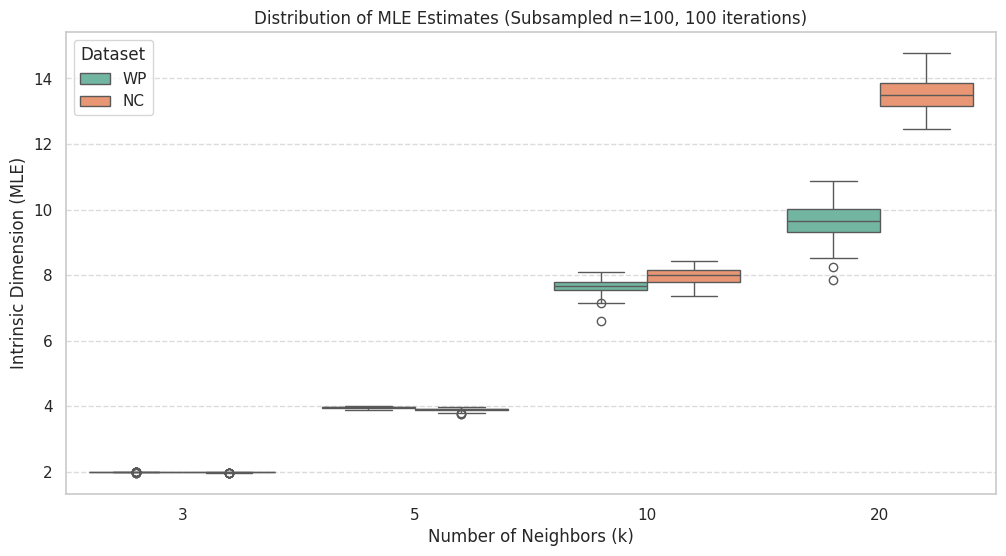

In [ ]:
plt.figure(figsize=(12, 6))

# Boxplot shows the quartiles and outliers clearly
sns.boxplot(data=df_dist,
             x='k_neighbors',
               y='MLE_Value',
                 hue='Dataset',
                   palette='Set2')

plt.title(f'Distribution of MLE Estimates (Subsampled n={sample_size}, {n_iterations} iterations)')
plt.ylabel('Intrinsic Dimension (MLE)')
plt.xlabel('Number of Neighbors (k)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Convergence Curve

The MLE estimator is essentially trying to solve for $D$ (dimension) in a density function. When $N$ is small, the distances to neighbors are large and noisy, making the estimator biased. As $N$ increases, the "true" manifold structure becomes clearer.

The Crossover Point: You will likely see the lines cross. If WP starts lower but has a steeper upward slope than NC, it confirms that WP's complexity requires more density to "activate" the estimator.

Testing convergence for: WP
running 10
k_10: 0.2653 s
running 10
k_10: 0.2489 s
running 10
k_10: 0.1779 s
running 10
k_10: 0.1881 s
running 10
k_10: 0.2223 s
running 10
k_10: 0.2213 s
running 10
k_10: 0.2211 s
running 10
k_10: 0.2213 s
running 10
k_10: 0.2223 s
running 10
k_10: 0.2221 s
running 10
k_10: 0.2212 s
running 10
k_10: 0.2083 s
running 10
k_10: 0.1926 s
running 10
k_10: 0.1908 s
running 10
k_10: 0.1889 s
running 10
k_10: 0.1898 s
running 10
k_10: 0.1884 s
running 10
k_10: 0.1881 s
running 10
k_10: 0.1885 s
running 10
k_10: 0.1932 s
running 10
k_10: 0.2250 s
running 10
k_10: 0.2244 s
running 10
k_10: 0.2226 s
running 10
k_10: 0.2212 s
running 10
k_10: 0.2205 s
running 10
k_10: 0.2158 s
running 10
k_10: 0.2141 s
running 10
k_10: 0.2246 s
running 10
k_10: 0.2247 s
running 10
k_10: 0.2253 s
running 10
k_10: 0.2242 s
running 10
k_10: 0.2250 s
running 10
k_10: 0.2237 s
running 10
k_10: 0.2089 s
running 10
k_10: 0.2046 s
running 10
k_10: 0.2117 s
running 10
k_10: 0.2363 s
running 10

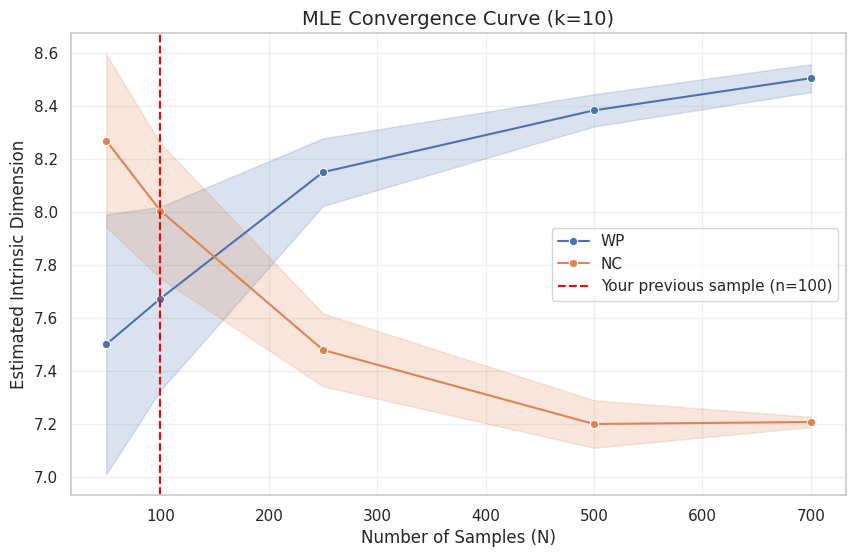

In [ ]:
# Configuration
sample_sizes = [50, 100, 250, 500, 700] # Adjust based on NC max size
n_iterations = 20  # Repeat to get distribution
k_to_plot = 10     # Focus on one k for the main line chart

results_list = []

for name, data in datasets_l.items():
    print(f"Testing convergence for: {name}")
    for n in sample_sizes:
        # Don't sample more than available points
        if n > data.shape[0]: continue 
        
        for i in range(n_iterations):
            idx = np.random.choice(data.shape[0], size=n, replace=False)
            res = calculate_MLE(dataset=data[idx],
                                 list_neighboors=[k_to_plot],
                                 verbose=False)
            
            results_list.append({
                'Dataset': name,
                'Sample Size': n,
                'MLE': res[k_to_plot]
            })

df_conv = pd.DataFrame(results_list)

# 2. Visualizing the Convergence
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_conv, x='Sample Size', y='MLE', hue='Dataset', marker='o', errorbar='sd')

plt.title(f'MLE Convergence Curve (k={k_to_plot})', fontsize=14)
plt.ylabel('Estimated Intrinsic Dimension')
plt.xlabel('Number of Samples (N)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### COnvergence for different K size

In [ ]:

# Configuration
sample_sizes = [50, 100, 250, 500, 700]
neighbors_list = [3, 10, 20]
n_iterations = 15

results_list = []

for name, data in datasets_l.items():
    print(f"Processing: {name}")
    for n in sample_sizes:
        if n > data.shape[0]: continue 
        
        for i in range(n_iterations):
            idx = np.random.choice(data.shape[0], size=n, replace=False)
            # Calculate MLE for all k at once for this specific sample
            res = calculate_MLE(dataset=data[idx],
                                 list_neighboors=neighbors_list,
                                 verbose=False)
            
            for k, val in res.items():
                results_list.append({
                    'Dataset': name,
                    'Sample Size': n,
                    'k': k,
                    'MLE': val
                })

df_interaction = pd.DataFrame(results_list)

# Plotting the interaction
# Using 'hue' for Dataset and 'style' (or row/col) for k to see the interplay
g = sns.relplot(
    data=df_interaction, 
    x='Sample Size', 
    y='MLE', 
    hue='Dataset', 
    col='k', 
    kind='line', 
    marker='o', 
    facet_kws={'sharey': False},
    errorbar='sd'
)

g.set_axis_labels("Sample Size (N)", "Intrinsic Dimension (MLE)")
g.set_titles("Neighbors k = {col_name}")
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Interaction between Sample Size and Neighbor Count (k)')

plt.show()

## COsine similarity

In [1]:
from sklearn.metrics.pairwise import cosine_distances

# For cosine similarity:
cost_matrix = cosine_distances(embeddings_nc, embeddings_wp)

NameError: name 'embeddings_nc' is not defined

In [ ]:
##• Test replacements of the cost matrix in pre-adaptation workflows to enhance the diversity/representativity of selected samples.
